In [1]:
from llrf_app.app import LLRFApp
from pprint import pprint
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import signal
from utils import calc_ps, plot_ps
import time

%load_ext autoreload
%autoreload 2

# Program bitstream file

In [2]:
!make -C ../top/marble_zest/ system_config MARBLE_SERIAL=42 GIT_32BIT_ID=ac140226 FSET=USPAS

make: Entering directory '/home/qdu/work/uspas_llrf/top/marble_zest'
Makefile:44: warning: overriding recipe for target '../../llrf_dsp/llrf_shell.json'
../../soc/marble_zest/common/llrf/rules.mk:12: warning: ignoring old recipe for target '../../llrf_dsp/llrf_shell.json'
Using Marble with serial number 42
openocd \
-c "adapter serial 000042;" \
-f marble.cfg \
-c "init; xc7_program xc7.tap; pld load 0 marble_zest_top_USPAS.ac140226.bit; exit"
Open On-Chip Debugger 0.12.0+dev-00519-gb6ee13720-dirty (2025-07-15-02:38)
Licensed under GNU GPL v2
For bug reports, read
	http://openocd.org/doc/doxygen/bugs.html
Info : auto-selecting first available session transport "jtag". To override use 'transport select <transport>'.
fpga_program
Info : ftdi: if you experience problems at higher adapter clocks, try the command "ftdi tdo_sample_edge falling"
Info : clock speed 15000 kHz
Info : JTAG tap: xc7.tap tap/device found: 0x0364c093 (mfg: 0x049 (Xilinx), part: 0x364c, ver: 0x0)
Info : [xc7.proxy] E

# Read Board Support info

In [3]:
llrf = LLRFApp(addr='192.168.19.42:803', conf='USPAS', chan_keep=0b1011)
llrf.get_bsp_info()

Marble Variant: V1.3
ADN4600 U2:
  IN 2 -> OUT 0
  IN 3 -> OUT 1
  IN 2 -> OUT 2
  IN 3 -> OUT 3
INA219 U57, 12V:
  Vshunt     :    -30.1 mV
  Power      :      1.1 mW
  Vbus       :     11.9 V
  Current    :  -1080.3 mA
INA219 U17, FMC1:
  Vshunt     :     19.0 mV
  Power      :     11.1 mW
  Vbus       :     11.9 V
  Current    :    195.6 mA
INA219 U32, FMC2:
  Vshunt     :    -21.6 mV
  Power      :     14.1 mW
  Vbus       :     11.9 V
  Current    :    132.2 mA
 PCA9555 U34, QSFP:
  I0         :    01111111
  I1         :    01001111
 PCA9555 U39, MISC:
  I0         :    11111110
  I1         :    11110011
QSFP 2 is present:
  Vendor     :    AVAGO           
  Part       :    AFBR-79EQDZ     
  Serial     :    QH3201VZ        
  TXRX_LOS   :    11111111
  Temp       :    48 C
  Volt       :    3260 mV
  TxBias0    :    0 uA
  TxPwr0     :    0 uW
  RxPwr0     :    0 uW
  TxBias1    :    0 uA
  TxPwr1     :    0 uW
  RxPwr1     :    0 uW
  TxBias2    :    0 uA
  TxPwr2     :    0 

In [4]:
pprint(llrf.model.cal_factors)

LLRFCalibrations(rx_gain=2.8343243166530288,
                 tx_gain=1.5484051512437744,
                 rx_phase_off_deg=65.64516888886018,
                 tx_phase_off_deg=15.652173913043494,
                 rx_dds_omega_deg=62.608695652173914,
                 tx_dds_omega_deg=31.304347826086957,
                 cic_wfm_gain=(7.113197508351704+0j),
                 inlk_gain=(0.36605409265367495+0j),
                 inlk_tx_gain=(0.1040617445044488+0.20083005046920652j),
                 rx_iq_gain=(1.7211517600548543+0j),
                 tx_iq_gain=(0.432586996690695-0.8348550064332301j),
                 max_adc_input=31129.6,
                 max_dac_drive=31129.6,
                 max_amp_setpoint=20104.298913623985)


## Measure a snapshot of RF amplitude and phases

* In open loop, set `amp_setpoint` to drive DAC output level at 20000 counts.
* The scaling factor of `tx_gain` is applied, which is the ratio from `amp_setpoint` to DAC output.
* The `max_amp_setpoint` is the maximum value of `amp_setpoint` before saturation.

In [5]:
open_loop_amp_sp = 2e4 / llrf.model.cal_factors.tx_gain
assert open_loop_amp_sp < llrf.model.cal_factors.max_amp_setpoint

llrf.reg_write([
    ('amp_setpoint', open_loop_amp_sp),
    ('phs_setpoint', 0),
    ('inlk_permit_mask', 0),
    ('dac_permit', 1),
    ('pulse_mode', 0)
])

An array of calibrated, complex RF levels at base-band are available by `llrf.get_rfmon()` function, which applies the `inlk_gain` and `inlk_tx_gain` to ADC and DAC channels respectively.

In [6]:
df_mon = llrf.get_rfmon()
df_mon

,mon_amp,mon_phs,Amp [cnt],Phs [deg]
adc0,7299,-9,19939.675984,-0.024719
adc1,3798,14886,10375.515740,40.885620
adc2,2,-32458,5.463673,-89.148560
adc3,3845,-7619,10503.912064,-20.926208
adc4,2,36366,5.463673,99.882202
adc5,0,-49138,0.000000,-134.961548
adc6,2,-49138,5.463673,-134.961548
adc7,2,-32458,5.463673,-89.148560
dac0,4523,22801,19996.533554,0.016121
dac1,4523,22801,19996.533554,0.016121


Confirm MO phase is aligned

In [7]:
mo_adc_chan = llrf.read_reg('prl_adc_chan')
fdbk_adc_chan = llrf.read_reg('fdbk_adc_chan')
mo_adc = f'adc{mo_adc_chan}'
fdbk_adc = f'adc{fdbk_adc_chan}'
print(f'MO ADC = {mo_adc}, FDBK ADC = {fdbk_adc}')

MO ADC = adc0, FDBK ADC = adc3


In [8]:
assert -0.2 < df_mon['Phs [deg]'][mo_adc] < 0.2

## Plot raw DAC / ADC data

In [9]:
df_sig = llrf.get_raw_bufs_df()

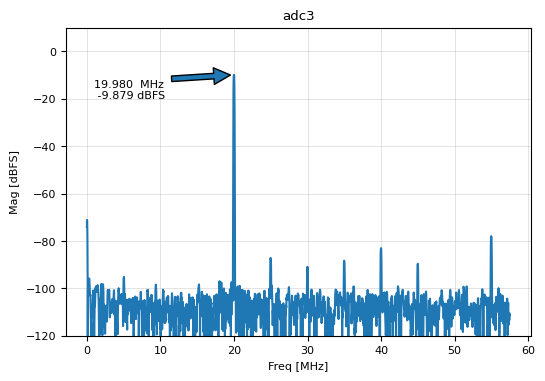

In [10]:
f, psd_dbfs = calc_ps(df_sig[fdbk_adc], fs_mhz=1e3/llrf.model.DSP_CLK_CYCLE)
plot_ps(f, psd_dbfs, title=fdbk_adc, annotate=True)

# Pulse mode test

In [11]:
# generate 4µs pulse
pulse_high_len = int(4000 / llrf.model.DSP_CLK_CYCLE)
llrf.reg_write([
    ('pulse_high_len', pulse_high_len),
    ('pulse_mode', 1)
])
time.sleep(0.5)

print(f'pulse_high_len: {pulse_high_len} counts')

pulse_high_len: 459 counts


<Axes: xlabel='Time [ns]'>

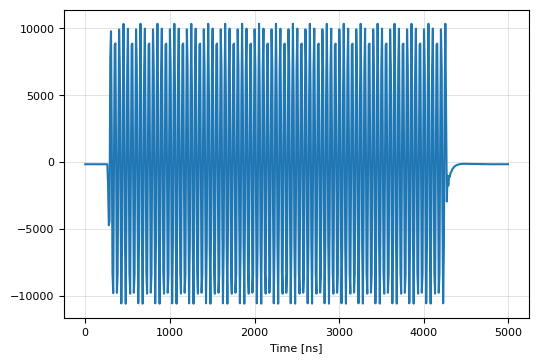

In [12]:
df_sig = llrf.get_raw_bufs_df()
df_sig[fdbk_adc].loc[:5000].plot()

In [13]:
df_iq = llrf.get_iq_wfms_df()

<Axes: xlabel='Time [ns]'>

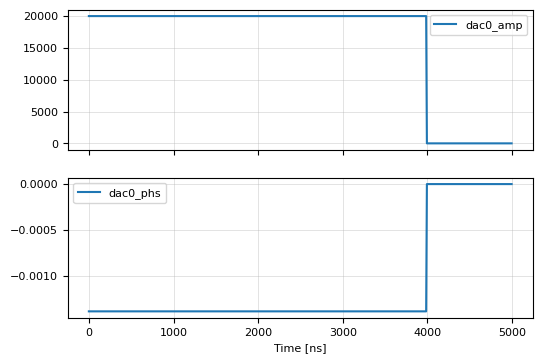

In [14]:
len_ns = 5000
fig, axes = plt.subplots(2, sharex=True)
df_iq[['dac0' + '_amp']].loc[:len_ns].plot(ax=axes[0])
df_iq[['dac0' + '_phs']].loc[:len_ns].plot(ax=axes[1])


<Axes: xlabel='Time [ns]'>

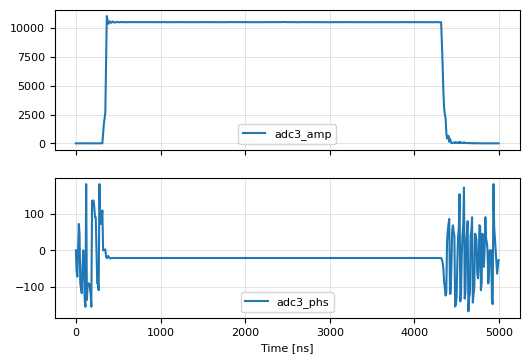

In [15]:
fig, axes = plt.subplots(2, sharex=True)
df_iq[[fdbk_adc + '_amp']].loc[:len_ns].plot(ax=axes[0])
df_iq[[fdbk_adc + '_phs']].loc[:len_ns].plot(ax=axes[1])


## Plot CIC circular buffer data

In [16]:
df_mp = llrf.get_cic_wfm_df()

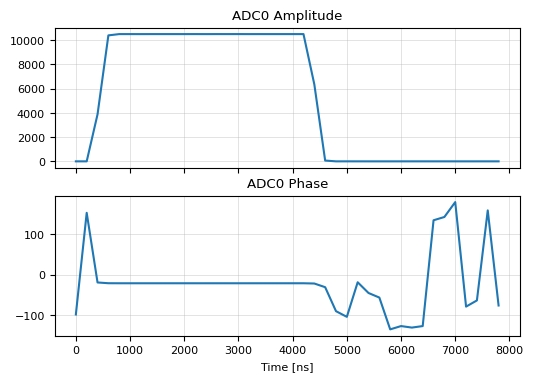

In [17]:
fig, axes = plt.subplots(2, sharex=True)
df_mp[fdbk_adc + '_amp'].loc[:8000].plot(title='ADC0 Amplitude', ax=axes[0]);
df_mp[fdbk_adc + '_phs'].loc[:8000].plot(title='ADC0 Phase', ax=axes[1]);